In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
retainx_df = pd.read_csv("../data/processed/retainx_hr_1000.csv")

In [3]:
retainx_df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,6253,31,Male,Divorced,Marketing,Assistant,3,13410,89,9,...,Yes,9,32,18,4,3,1,34,4,No
1,4685,25,Male,Divorced,HR,Analyst,3,11034,66,12,...,No,2,58,18,1,4,1,23,1,Yes
2,1732,50,Female,Divorced,IT,Assistant,5,18595,56,24,...,Yes,2,42,4,4,4,4,39,3,Yes
3,4743,36,Male,Divorced,Sales,Executive,4,13160,65,17,...,Yes,1,41,3,4,4,4,39,4,Yes
4,4522,43,Female,Married,Finance,Analyst,5,14131,44,16,...,No,7,48,5,2,1,1,1,4,Yes


In [4]:
dept_headcount=(retainx_df["Department"].value_counts().sort_values(ascending=False))
print(dept_headcount)

Department
Marketing    216
Finance      208
Sales        203
IT           191
HR           182
Name: count, dtype: int64


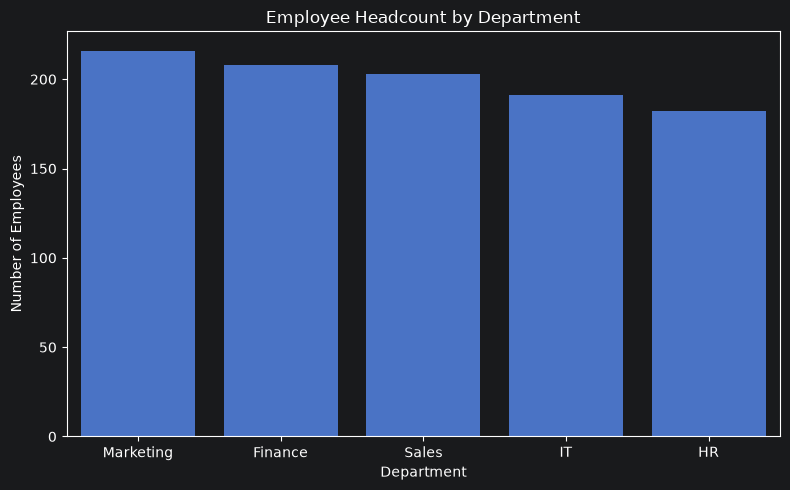

In [5]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=retainx_df,
    x="Department",
    order=dept_headcount.index
)

plt.title("Employee Headcount by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [6]:
dept_attrition=((retainx_df["Attrition"]=="Yes").groupby(retainx_df["Department"]).mean()*100).sort_values(ascending=False)
print(dept_attrition)

Department
Finance      23.557692
Marketing    22.222222
IT           20.942408
Sales        19.704433
HR           19.230769
Name: Attrition, dtype: float64


In [7]:
total_employees = len(retainx_df)
employees_left = (retainx_df["Attrition"] == "Yes").sum()

company_attrition_rate = (employees_left / total_employees) * 100
print(f"Company Attrition Rate: {company_attrition_rate:.2f}%")

Company Attrition Rate: 21.20%


In [10]:
dept_comparision = pd.DataFrame(
    {
        "Department Attrition %": dept_attrition,
        "Difference from avg": dept_attrition - company_attrition_rate
    }
)

dept_comparision = dept_comparision.sort_values(by="Department Attrition %", ascending=False)
print(dept_comparision)

            Department Attrition %  Difference from avg
Department                                             
Finance                  23.557692             2.357692
Marketing                22.222222             1.022222
IT                       20.942408            -0.257592
Sales                    19.704433            -1.495567
HR                       19.230769            -1.969231


In [11]:
overtime_attrition=((retainx_df["Attrition"] == "Yes").groupby(retainx_df["Overtime"]).mean()*100).sort_values(ascending=False)
print(overtime_attrition)

Overtime
Yes    21.382289
No     21.042831
Name: Attrition, dtype: float64


In [14]:
company_rate = (retainx_df["Attrition"] == "Yes").mean() * 100

overtime_rate = (retainx_df["Attrition"] == "Yes").groupby(retainx_df["Overtime"]).mean() * 100

comparison = pd.DataFrame({
    "Quit Rate %": overtime_rate,
    "Difference from Avg": overtime_rate - company_rate
})

print(f"Company Average: {company_rate:.2f}%\n")
print(comparison.round(2))

Company Average: 21.20%

          Quit Rate %  Difference from Avg
Overtime                                  
No              21.04                -0.16
Yes             21.38                 0.18


In [15]:
satisfaction_attrition = (
        (retainx_df["Attrition"] == "Yes")
        .groupby(retainx_df["Job_Satisfaction"])
        .mean() * 100
)

satisfaction_attrition = satisfaction_attrition.sort_index()

print(satisfaction_attrition.round(2))

Job_Satisfaction
1    26.26
2    23.08
3    21.36
4    20.81
5    14.72
Name: Attrition, dtype: float64


In [16]:
satisfaction_comparison = pd.DataFrame({
    "Attrition Rate %": satisfaction_attrition,
    "Difference from Company Rate":
        satisfaction_attrition - company_rate
})

print(satisfaction_comparison.round(2))

                  Attrition Rate %  Difference from Company Rate
Job_Satisfaction                                                
1                            26.26                          5.06
2                            23.08                          1.88
3                            21.36                          0.16
4                            20.81                         -0.39
5                            14.72                         -6.48


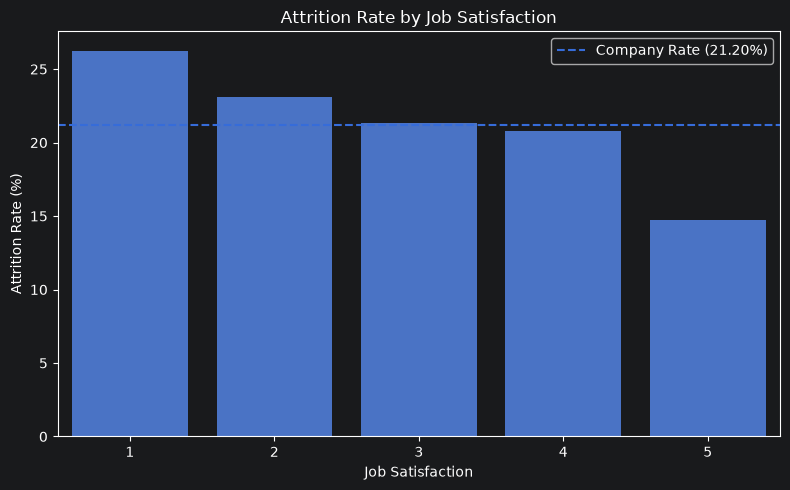

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=satisfaction_attrition.index,
    y=satisfaction_attrition.values
)

plt.axhline(
    company_rate,
    linestyle="--",
    label=f"Company Rate ({company_rate:.2f}%)"
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
salary_summary = (
    retainx_df
    .groupby("Attrition")["Monthly_Income"]
    .agg(["count", "mean", "median"])
)

print(salary_summary.round(2))

           count      mean   median
Attrition                          
No           788  11361.95  11478.0
Yes          212  11656.33  11860.0


In [19]:
promotion_attrition = (
        (retainx_df["Attrition"] == "Yes")
        .groupby(retainx_df["Years_Since_Last_Promotion"])
        .mean() * 100
)

print(promotion_attrition.round(2))

Years_Since_Last_Promotion
0    19.00
1    17.20
2    18.18
3    23.75
4    20.93
5    23.71
6    17.27
7    24.32
8    21.21
9    26.32
Name: Attrition, dtype: float64


In [20]:
promotion_summary = (
    retainx_df
    .groupby("Years_Since_Last_Promotion")
    .agg(Employees=("Employee_ID", "count"),
        Attrition_Rate=("Attrition", lambda x: (x == "Yes").mean() * 100)
    )
)

print(promotion_summary.round(2))

                            Employees  Attrition_Rate
Years_Since_Last_Promotion                           
0                                 100           19.00
1                                  93           17.20
2                                 110           18.18
3                                  80           23.75
4                                  86           20.93
5                                  97           23.71
6                                 110           17.27
7                                 111           24.32
8                                  99           21.21
9                                 114           26.32


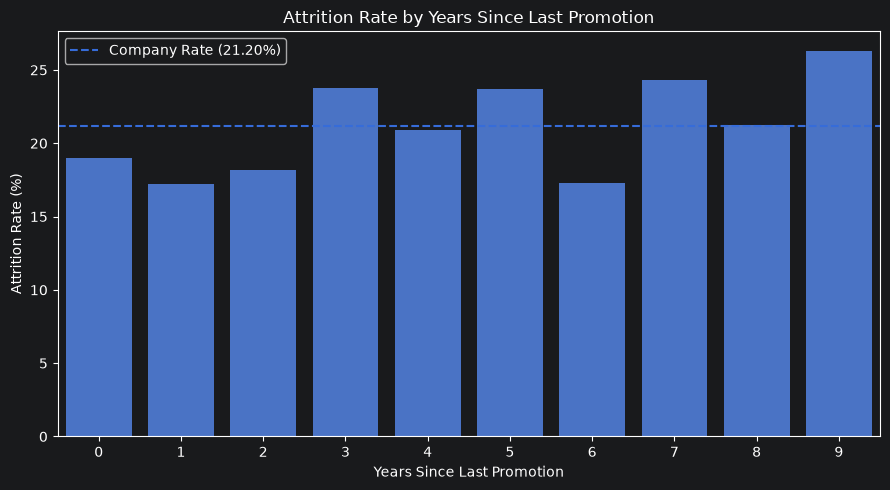

In [21]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=promotion_summary.index,
    y=promotion_summary["Attrition_Rate"]
)

plt.axhline(
    company_rate,
    linestyle="--",
    label=f"Company Rate ({company_rate:.2f}%)"
)

plt.title("Attrition Rate by Years Since Last Promotion")
plt.xlabel("Years Since Last Promotion")
plt.ylabel("Attrition Rate (%)")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
hours_attrition = (
        (retainx_df["Attrition"] == "Yes")
        .groupby(retainx_df["Average_Hours_Worked_Per_Week"])
        .mean() * 100
)

print(hours_attrition.round(2))

Average_Hours_Worked_Per_Week
30    23.53
31    12.50
32    11.63
33    20.59
34    27.27
35    21.43
36    33.33
37    20.00
38    23.53
39    17.86
40    30.30
41    24.14
42    16.67
43    18.92
44    15.15
45    20.00
46    22.58
47    20.51
48    23.53
49    30.00
50    23.33
51    13.64
52    22.22
53    30.30
54    21.21
55    26.19
56    17.24
57     8.00
58    23.08
59    16.22
Name: Attrition, dtype: float64
